In [1]:
!pip install pyspark -q

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
spark = SparkSession.builder \
    .appName("Retail Banking Analytics") \
    .getOrCreate()

In [4]:
from google.colab import files

uploaded = files.upload()

Saving Churn_Modelling.csv to Churn_Modelling (1).csv


In [5]:
import os

os.rename("Churn_Modelling (1).csv", "Churn_Modelling.csv")

In [6]:
data = spark.read.csv(
    "Churn_Modelling.csv",
    header=True,
    inferSchema=True
)

data.show(5)

+---------+----------+--------+-----------+---------+------+---+------+---------+-------------+---------+--------------+---------------+------+
|RowNumber|CustomerId| Surname|CreditScore|Geography|Gender|Age|Tenure|  Balance|NumOfProducts|HasCrCard|IsActiveMember|EstimatedSalary|Exited|
+---------+----------+--------+-----------+---------+------+---+------+---------+-------------+---------+--------------+---------------+------+
|        1|  15634602|Hargrave|        619|   France|Female| 42|     2|      0.0|            1|        1|             1|      101348.88|     1|
|        2|  15647311|    Hill|        608|    Spain|Female| 41|     1| 83807.86|            1|        0|             1|      112542.58|     0|
|        3|  15619304|    Onio|        502|   France|Female| 42|     8| 159660.8|            3|        1|             0|      113931.57|     1|
|        4|  15701354|    Boni|        699|   France|Female| 39|     1|      0.0|            2|        0|             0|       93826.63|

In [7]:
data.printSchema()

root
 |-- RowNumber: integer (nullable = true)
 |-- CustomerId: integer (nullable = true)
 |-- Surname: string (nullable = true)
 |-- CreditScore: integer (nullable = true)
 |-- Geography: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Tenure: integer (nullable = true)
 |-- Balance: double (nullable = true)
 |-- NumOfProducts: integer (nullable = true)
 |-- HasCrCard: integer (nullable = true)
 |-- IsActiveMember: integer (nullable = true)
 |-- EstimatedSalary: double (nullable = true)
 |-- Exited: integer (nullable = true)



In [8]:
data.count()

10000

In [9]:
len(data.columns)

14

In [13]:
data.describe().show()

+-------+------------------+-----------------+-------+-----------------+---------+------+------------------+------------------+-----------------+------------------+-------------------+-------------------+-----------------+-------------------+
|summary|         RowNumber|       CustomerId|Surname|      CreditScore|Geography|Gender|               Age|            Tenure|          Balance|     NumOfProducts|          HasCrCard|     IsActiveMember|  EstimatedSalary|             Exited|
+-------+------------------+-----------------+-------+-----------------+---------+------+------------------+------------------+-----------------+------------------+-------------------+-------------------+-----------------+-------------------+
|  count|             10000|            10000|  10000|            10000|    10000| 10000|             10000|             10000|            10000|             10000|              10000|              10000|            10000|              10000|
|   mean|            5000.5|

In [14]:
data.select("Exited").groupBy("Exited").count().show()

+------+-----+
|Exited|count|
+------+-----+
|     1| 2037|
|     0| 7963|
+------+-----+



customers stayed (0) and customers left (1)

In [15]:
data = data.drop("RowNumber", "CustomerId", "Surname")

In [16]:
data.printSchema()

root
 |-- CreditScore: integer (nullable = true)
 |-- Geography: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Tenure: integer (nullable = true)
 |-- Balance: double (nullable = true)
 |-- NumOfProducts: integer (nullable = true)
 |-- HasCrCard: integer (nullable = true)
 |-- IsActiveMember: integer (nullable = true)
 |-- EstimatedSalary: double (nullable = true)
 |-- Exited: integer (nullable = true)



In [17]:
from pyspark.sql.functions import col, sum

data.select([sum(col(c).isNull().cast("int")).alias(c) for c in data.columns]).show()

+-----------+---------+------+---+------+-------+-------------+---------+--------------+---------------+------+
|CreditScore|Geography|Gender|Age|Tenure|Balance|NumOfProducts|HasCrCard|IsActiveMember|EstimatedSalary|Exited|
+-----------+---------+------+---+------+-------+-------------+---------+--------------+---------------+------+
|          0|        0|     0|  0|     0|      0|            0|        0|             0|              0|     0|
+-----------+---------+------+---+------+-------+-------------+---------+--------------+---------------+------+



In [18]:
data.show(5)

+-----------+---------+------+---+------+---------+-------------+---------+--------------+---------------+------+
|CreditScore|Geography|Gender|Age|Tenure|  Balance|NumOfProducts|HasCrCard|IsActiveMember|EstimatedSalary|Exited|
+-----------+---------+------+---+------+---------+-------------+---------+--------------+---------------+------+
|        619|   France|Female| 42|     2|      0.0|            1|        1|             1|      101348.88|     1|
|        608|    Spain|Female| 41|     1| 83807.86|            1|        0|             1|      112542.58|     0|
|        502|   France|Female| 42|     8| 159660.8|            3|        1|             0|      113931.57|     1|
|        699|   France|Female| 39|     1|      0.0|            2|        0|             0|       93826.63|     0|
|        850|    Spain|Female| 43|     2|125510.82|            1|        1|             1|        79084.1|     0|
+-----------+---------+------+---+------+---------+-------------+---------+-------------

**some simple business analysis using PySpark**

In [19]:
data.groupBy("Geography").count().show()

+---------+-----+
|Geography|count|
+---------+-----+
|  Germany| 2509|
|   France| 5014|
|    Spain| 2477|
+---------+-----+



In [20]:
data.groupBy("Gender").count().show()

+------+-----+
|Gender|count|
+------+-----+
|Female| 4543|
|  Male| 5457|
+------+-----+



In [21]:
data.groupBy("Exited").agg(avg("Age")).show()

+------+-----------------+
|Exited|         avg(Age)|
+------+-----------------+
|     1| 44.8379970544919|
|     0|37.40838879819164|
+------+-----------------+



In [22]:
data.groupBy("Exited").agg(avg("Balance")).show()

+------+-----------------+
|Exited|     avg(Balance)|
+------+-----------------+
|     1|91108.53933726063|
|     0|72745.29677885193|
+------+-----------------+



In [23]:
data.groupBy("Exited").agg(avg("CreditScore")).show()

+------+-----------------+
|Exited| avg(CreditScore)|
+------+-----------------+
|     1|645.3514972999509|
|     0|651.8531960316463|
+------+-----------------+



In [24]:
data.groupBy("IsActiveMember").agg(count("*").alias("Customers")).show()

+--------------+---------+
|IsActiveMember|Customers|
+--------------+---------+
|             1|     5151|
|             0|     4849|
+--------------+---------+



visualizations using Pandas and Matplotlib

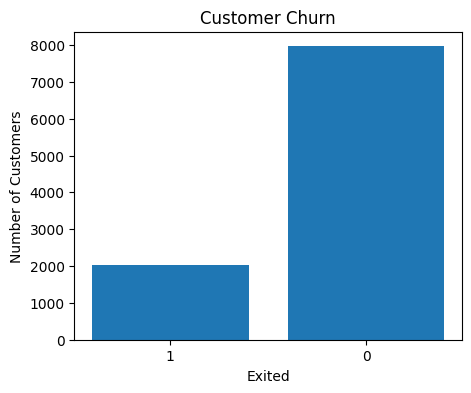

In [25]:
exit_data = data.groupBy("Exited").count().toPandas()

plt.figure(figsize=(5,4))
plt.bar(exit_data["Exited"].astype(str), exit_data["count"])
plt.title("Customer Churn")
plt.xlabel("Exited")
plt.ylabel("Number of Customers")
plt.show()

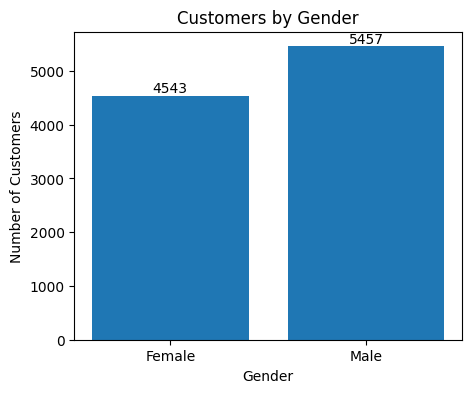

In [44]:
gender_data = data.groupBy("Gender").count().toPandas()

plt.figure(figsize=(5,4))
plt.bar(gender_data["Gender"], gender_data["count"])
plt.bar_label(plt.gca().containers[0])
plt.title("Customers by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

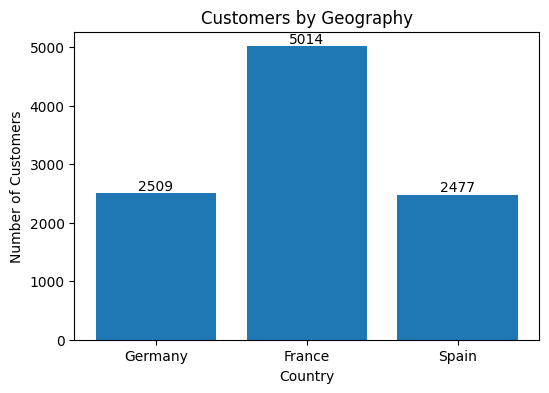

In [38]:
geo_data = data.groupBy("Geography").count().toPandas()

plt.figure(figsize=(6,4))
bars = plt.bar(geo_data["Geography"], geo_data["count"])
plt.bar_label(bars)
plt.title("Customers by Geography")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.show()

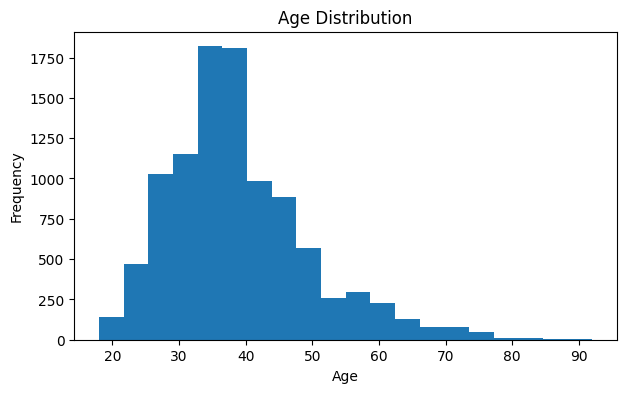

In [41]:
age_data = data.select("Age").toPandas()

plt.figure(figsize=(7,4))
plt.hist(age_data["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

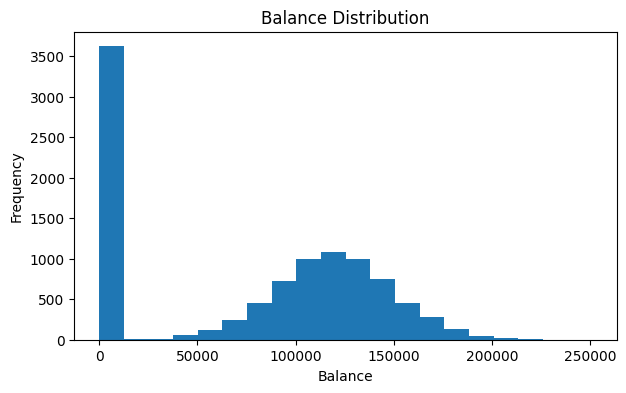

In [29]:
balance_data = data.select("Balance").toPandas()

plt.figure(figsize=(7,4))
plt.hist(balance_data["Balance"], bins=20)
plt.title("Balance Distribution")
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.show()

**now we use Spark SQL**

In [30]:
data.createOrReplaceTempView("customers")

In [31]:
spark.sql("""
SELECT Geography, COUNT(*) AS Customers
FROM customers
GROUP BY Geography
ORDER BY Customers DESC
""").show()

+---------+---------+
|Geography|Customers|
+---------+---------+
|   France|     5014|
|  Germany|     2509|
|    Spain|     2477|
+---------+---------+



In [32]:
spark.sql("""
SELECT Gender, AVG(Balance) AS Average_Balance
FROM customers
GROUP BY Gender
""").show()

+------+-----------------+
|Gender|  Average_Balance|
+------+-----------------+
|Female|75659.36913933513|
|  Male|77173.97450613906|
+------+-----------------+



In [33]:
spark.sql("""
SELECT Geography, AVG(CreditScore) AS Average_CreditScore
FROM customers
GROUP BY Geography
""").show()

+---------+-------------------+
|Geography|Average_CreditScore|
+---------+-------------------+
|  Germany|  651.4535671582304|
|   France|  649.6683286796969|
|    Spain|  651.3338716188938|
+---------+-------------------+



**business focused analysis**

In [45]:
churn_country = data.groupBy("Geography", "Exited").count().toPandas()

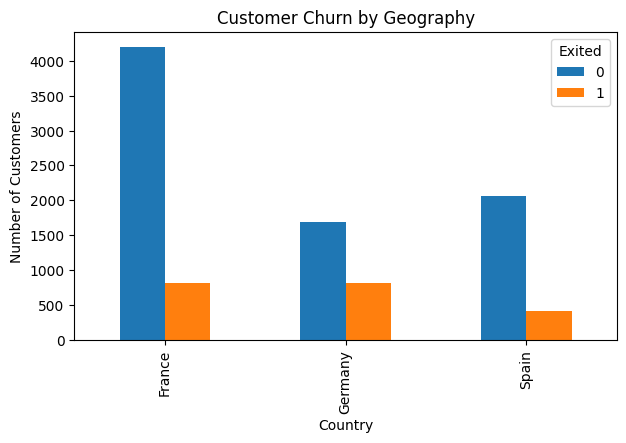

In [46]:
pivot = churn_country.pivot(index="Geography", columns="Exited", values="count")

pivot.plot(kind="bar", figsize=(7,4))

plt.title("Customer Churn by Geography")
plt.xlabel("Country")
plt.ylabel("Number of Customers")

plt.show()

In [47]:
churn_gender = data.groupBy("Gender", "Exited").count().toPandas()

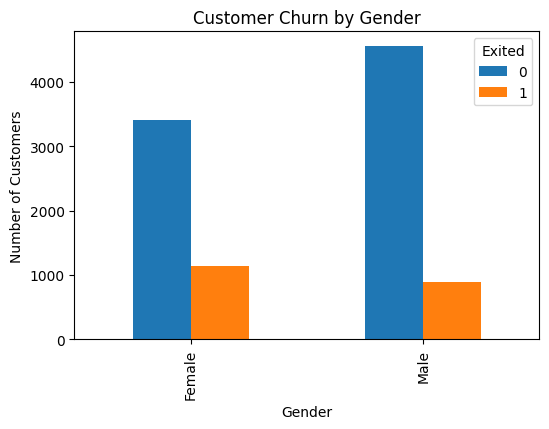

In [48]:
pivot = churn_gender.pivot(index="Gender", columns="Exited", values="count")

pivot.plot(kind="bar", figsize=(6,4))

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

In [49]:
age_churn = data.groupBy("Exited").agg(avg("Age")).toPandas()

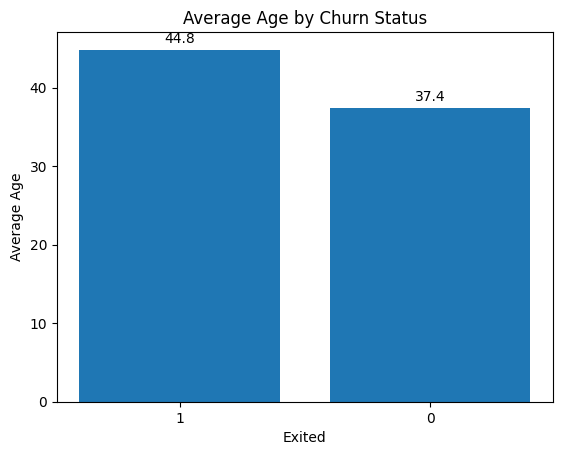

In [50]:
bars = plt.bar(age_churn["Exited"].astype(str), age_churn["avg(Age)"])

plt.bar_label(bars, fmt="%.1f", padding=3)

plt.title("Average Age by Churn Status")
plt.xlabel("Exited")
plt.ylabel("Average Age")

plt.show()

In [51]:
balance_churn = data.groupBy("Exited").agg(avg("Balance")).toPandas()

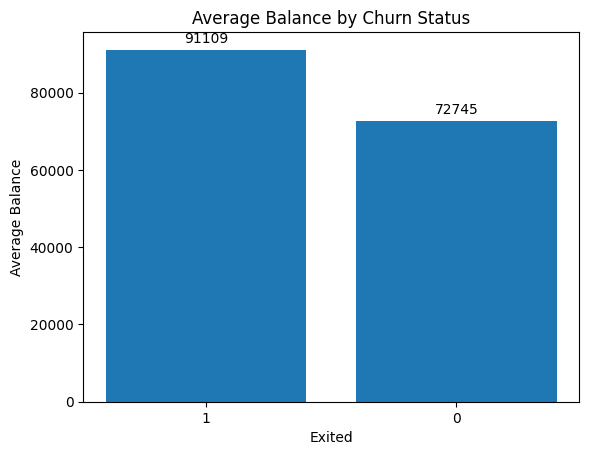

In [52]:
bars = plt.bar(balance_churn["Exited"].astype(str), balance_churn["avg(Balance)"])

plt.bar_label(bars, fmt="%.0f", padding=3)

plt.title("Average Balance by Churn Status")
plt.xlabel("Exited")
plt.ylabel("Average Balance")

plt.show()

moving to ML model using Pyspark ML

In [53]:
from pyspark.ml.feature import StringIndexer

In [54]:
geo_index = StringIndexer(inputCol="Geography", outputCol="GeographyIndex")
gender_index = StringIndexer(inputCol="Gender", outputCol="GenderIndex")

data = geo_index.fit(data).transform(data)
data = gender_index.fit(data).transform(data)

In [55]:
from pyspark.ml.feature import VectorAssembler

In [56]:
assembler = VectorAssembler(
    inputCols=[
        "CreditScore",
        "GeographyIndex",
        "GenderIndex",
        "Age",
        "Tenure",
        "Balance",
        "NumOfProducts",
        "HasCrCard",
        "IsActiveMember",
        "EstimatedSalary"
    ],
    outputCol="features"
)

model_data = assembler.transform(data)

In [57]:
final_data = model_data.select("features", "Exited")

In [58]:
train_data, test_data = final_data.randomSplit([0.8, 0.2], seed=42)

In [59]:
from pyspark.ml.classification import LogisticRegression

In [60]:
lr = LogisticRegression(labelCol="Exited", featuresCol="features")

model = lr.fit(train_data)

In [61]:
predictions = model.transform(test_data)

In [62]:
predictions.select("Exited", "prediction", "probability").show(10, truncate=False)

+------+----------+----------------------------------------+
|Exited|prediction|probability                             |
+------+----------+----------------------------------------+
|0     |0.0       |[0.8638747975951269,0.13612520240487314]|
|0     |0.0       |[0.8116666490133047,0.18833335098669535]|
|1     |0.0       |[0.6273676611065957,0.3726323388934043] |
|1     |0.0       |[0.9073631812000994,0.0926368187999006] |
|0     |0.0       |[0.8673424256734416,0.13265757432655845]|
|1     |0.0       |[0.7638127273659502,0.23618727263404982]|
|1     |0.0       |[0.5727522854805526,0.42724771451944743]|
|0     |0.0       |[0.9083358286411319,0.09166417135886806]|
|0     |0.0       |[0.8789968356581667,0.12100316434183334]|
|0     |0.0       |[0.8780810413328487,0.1219189586671513] |
+------+----------+----------------------------------------+
only showing top 10 rows


In [64]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

In [66]:
evaluator = BinaryClassificationEvaluator(
    labelCol="Exited",
    metricName="areaUnderROC"
)

auc = evaluator.evaluate(predictions)

print("AUC Score:", __builtins__.round(auc, 3))

AUC Score: 0.759


In [67]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [71]:
accuracy = MulticlassClassificationEvaluator(
    labelCol="Exited",
    predictionCol="prediction",
    metricName="accuracy"
)

print("Accuracy:", __builtins__.round(accuracy.evaluate(predictions), 3))

Accuracy: 0.806


analytics part

In [73]:
model.coefficients

DenseVector([-0.0007, 0.0907, 0.5474, 0.0725, -0.0093, 0.0, -0.0313, -0.0087, -1.0533, 0.0])

In [72]:
features = [
    "CreditScore",
    "Geography",
    "Gender",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary"
]

importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coefficients
})

importance

,Feature,Coefficient
0,CreditScore,-7.483105e-04
1,Geography,9.068569e-02
2,Gender,5.473869e-01
3,Age,7.251895e-02
4,Tenure,-9.289502e-03
5,Balance,4.945344e-06
6,NumOfProducts,-3.130863e-02
7,HasCrCard,-8.656110e-03
8,IsActiveMember,-1.053274e+00
9,EstimatedSalary,6.848075e-07


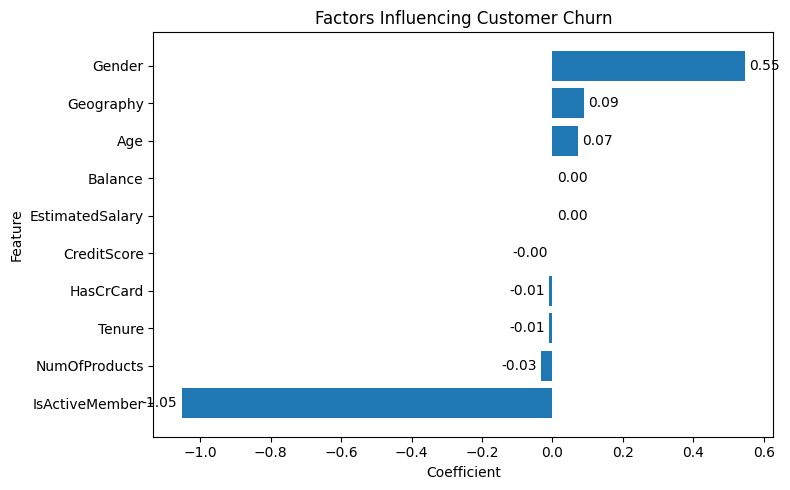

In [76]:
importance["Coefficient"] = importance["Coefficient"].astype(float)

importance = importance.sort_values("Coefficient")

plt.figure(figsize=(8,5))

bars = plt.barh(importance["Feature"], importance["Coefficient"])

plt.bar_label(bars, fmt="%.2f", padding=3)

plt.title("Factors Influencing Customer Churn")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

**Key Findings**

- France had the highest number of customers.
- Older customers showed a higher tendency to churn.
- Active members were less likely to leave the bank.
- Customers with higher balances showed a greater churn rate.
- Credit score had a relatively small impact compared to customer activity and age.

**Business Recommendations**

- Offer personalized retention campaigns for high-risk customers.
- Increase customer engagement through loyalty programs.
- Monitor inactive customers and encourage regular account usage.
- Provide targeted financial products based on customer behavior.
- Use predictive analytics to identify customers likely to churn.

In [77]:
model.save("bank_churn_model")

In [78]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [79]:
prediction_data = predictions.select("Exited", "prediction").toPandas()

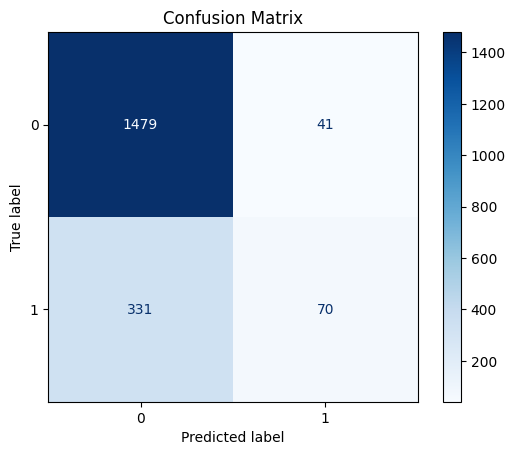

In [80]:
cm = confusion_matrix(
    prediction_data["Exited"],
    prediction_data["prediction"]
)

display = ConfusionMatrixDisplay(confusion_matrix=cm)

display.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [81]:
import seaborn as sns

In [82]:
corr_data = data.toPandas()

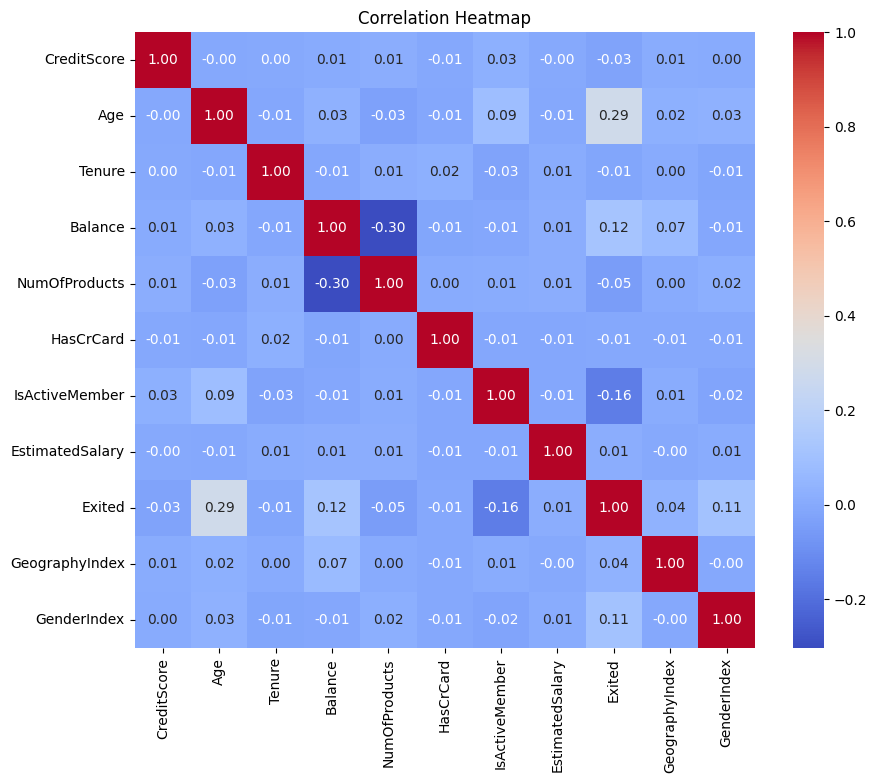

In [83]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_data.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [88]:
high_risk = predictions.select("Exited","prediction","probability").toPandas()

high_risk["Churn_Probability"] = high_risk["probability"].apply(lambda x: __builtins__.round(x[1], 2))

high_risk.sort_values("Churn_Probability", ascending=False).head(10)

,Exited,prediction,probability,Churn_Probability
35,1,1.0,"[0.06315307171068367, 0.9368469282893164]",0.94
1307,1,1.0,"[0.18114848756023993, 0.8188515124397601]",0.82
186,0,1.0,"[0.18702564039596736, 0.8129743596040326]",0.81
315,1,1.0,"[0.23230369501337036, 0.7676963049866297]",0.77
1678,1,1.0,"[0.2425034182356616, 0.7574965817643384]",0.76
1057,0,1.0,"[0.26366510779495805, 0.7363348922050419]",0.74
166,0,1.0,"[0.2638284730490004, 0.7361715269509996]",0.74
1658,1,1.0,"[0.26300713083371435, 0.7369928691662857]",0.74
500,1,1.0,"[0.27465694912233857, 0.7253430508776615]",0.73
1285,1,1.0,"[0.2752721712342405, 0.7247278287657595]",0.72
